<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9F%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%BE%D0%B9_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_%D0%B4%D0%BB%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%D1%81_%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%D0%BC_BatchNormalization_%D0%B8_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [ ]:
# 1.1 Загрузка исходного датасета CIFAR-100 и разбиение на train/test
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow.keras import layers, models, callbacks

SEED = 42
BATCH_SIZE = 128
EPOCHS = 20

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Используем sparse-метки: y имеют форму (N, 1) и содержат целочисленные классы 0..99
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode="fine")
y_train = y_train.squeeze()
y_test = y_test.squeeze()

num_classes = 100
input_shape = x_train.shape[1:]

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}, y_test:  {y_test.shape}")
print(f"input_shape: {input_shape}, num_classes: {num_classes}")


def make_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1,
        ),
    ]


def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
x_train: (50000, 32, 32, 3), y_train: (50000,)
x_test:  (10000, 32, 32, 3), y_test:  (10000,)
input_shape: (32, 32, 3), num_classes: 100


### **1.2. Визуализируйте несколько изображений из датасета:**


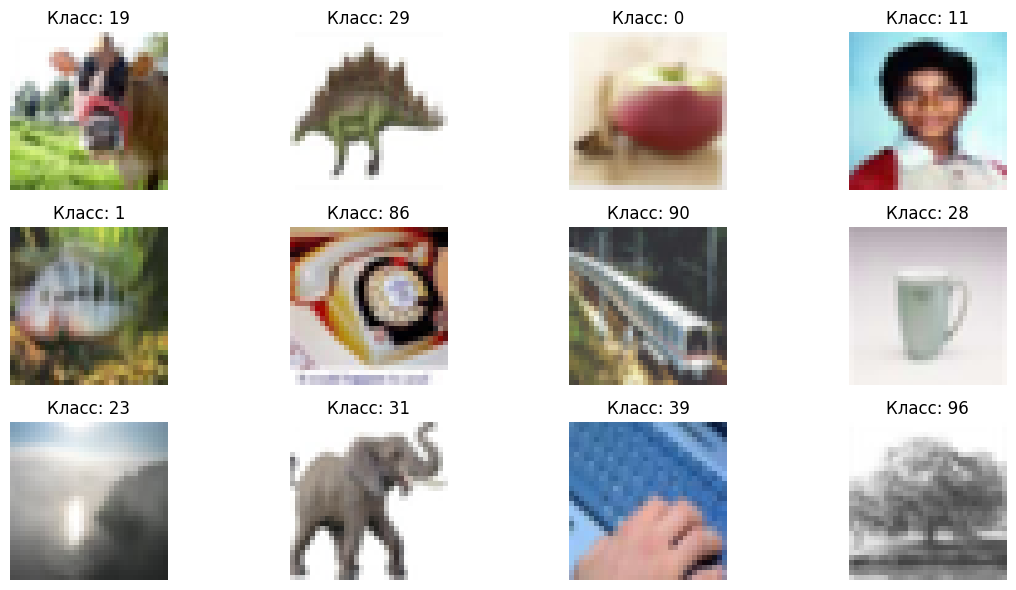

In [ ]:
# 1.2 Визуализация нескольких изображений из датасета
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"Класс: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [ ]:
# 1.3 Нормализация данных в диапазон [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Диапазон train:", x_train_norm.min(), x_train_norm.max())
print("Диапазон test:", x_test_norm.min(), x_test_norm.max())

Диапазон train: 0.0 1.0
Диапазон test: 0.0 1.0


### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [ ]:
# 1.4 Модель без BatchNormalization и Dropout (model_1)
model_1 = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_1_base",
)

model_1 = compile_model(model_1)
model_1.summary()

Model: "model_1_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,356 (8.45 MB)

 Trainable params: 2,216,356 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [ ]:
# Обучение model_1
history_1 = model_1.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_1, test_acc_1 = model_1.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_1 test accuracy: {test_acc_1:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.1277 - loss: 3.7887 - val_accuracy: 0.2055 - val_loss: 3.3099 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2675 - loss: 3.0006 - val_accuracy: 0.2863 - val_loss: 2.8967 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3480 - loss: 2.5953 - val_accuracy: 0.3238 - val_loss: 2.7228 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4067 - loss: 2.3117 - val_accuracy: 0.3388 - val_loss: 2.7166 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4659 - loss: 2.0510 - val_accuracy: 0.3401 - val_loss: 2.7977 - learning_rate: 0.0010
Epoch 6/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5098 - loss: 1.8497
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5249 - loss: 1.7956 

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [ ]:
# 1.5 Модель с BatchNormalization (model_2)
model_2 = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_2_batchnorm",
)

model_2 = compile_model(model_2)
model_2.summary()

Model: "model_2_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,217,252 (8.46 MB)

 Trainable params: 2,216,804 (8.46 MB)

 Non-trainable params: 448 (1.75 KB)

Обучите созданную модель

In [ ]:
# Обучение model_2
history_2 = model_2.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_2, test_acc_2 = model_2.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_2 test accuracy: {test_acc_2:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1468 - loss: 3.7110 - val_accuracy: 0.0450 - val_loss: 5.2395 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3068 - loss: 2.7455 - val_accuracy: 0.2682 - val_loss: 2.9195 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3983 - loss: 2.3175 - val_accuracy: 0.3160 - val_loss: 2.7102 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4582 - loss: 2.0407 - val_accuracy: 0.3352 - val_loss: 2.6547 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5142 - loss: 1.8085 - val_accuracy: 0.3284 - val_loss: 2.7527 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5461 - loss: 1.6726
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5623 - loss: 1.6073 

### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [ ]:
# 1.6 Модель с Dropout (model_3)
model_3 = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_3_dropout",
)

model_3 = compile_model(model_3)
model_3.summary()

Model: "model_3_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,356 (8.45 MB)

 Trainable params: 2,216,356 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [ ]:
# Обучение model_3
history_3 = model_3.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_3, test_acc_3 = model_3.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_3 test accuracy: {test_acc_3:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.0461 - loss: 4.2868 - val_accuracy: 0.1108 - val_loss: 3.8815 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1184 - loss: 3.7829 - val_accuracy: 0.1806 - val_loss: 3.4323 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1714 - loss: 3.4747 - val_accuracy: 0.2352 - val_loss: 3.1386 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2073 - loss: 3.2724 - val_accuracy: 0.2604 - val_loss: 3.0103 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2325 - loss: 3.1251 - val_accuracy: 0.2853 - val_loss: 2.9039 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2560 - loss: 3.0000 - val_accuracy: 0.2966 - val_loss: 2.8462 - learning_rate: 0.0010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2744 - loss: 2.9054 

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [ ]:
# 1.7 Модель с BatchNormalization + Dropout (model_4)
# Рекомендуемый порядок: Conv -> BatchNorm -> ReLU -> Pooling -> Dropout
model_4 = models.Sequential(
    [
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_4_bn_dropout",
)

model_4 = compile_model(model_4)
model_4.summary()

Model: "model_4_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,217,252 (8.46 MB)

 Trainable params: 2,216,804 (8.46 MB)

 Non-trainable params: 448 (1.75 KB)

Обучите созданную модель

In [ ]:
# Обучение model_4
history_4 = model_4.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_4, test_acc_4 = model_4.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_4 test accuracy: {test_acc_4:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0154 - loss: 4.5702 - val_accuracy: 0.0201 - val_loss: 4.5582 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0261 - loss: 4.4566 - val_accuracy: 0.0448 - val_loss: 4.3831 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0343 - loss: 4.3838 - val_accuracy: 0.0491 - val_loss: 4.2724 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0406 - loss: 4.3019 - val_accuracy: 0.0591 - val_loss: 4.2769 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0474 - loss: 4.2077 - val_accuracy: 0.0843 - val_loss: 4.0540 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0575 - loss: 4.1173 - val_accuracy: 0.1074 - val_loss: 3.8911 - learning_rate: 0.0010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0658 - loss: 4.0312 

### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

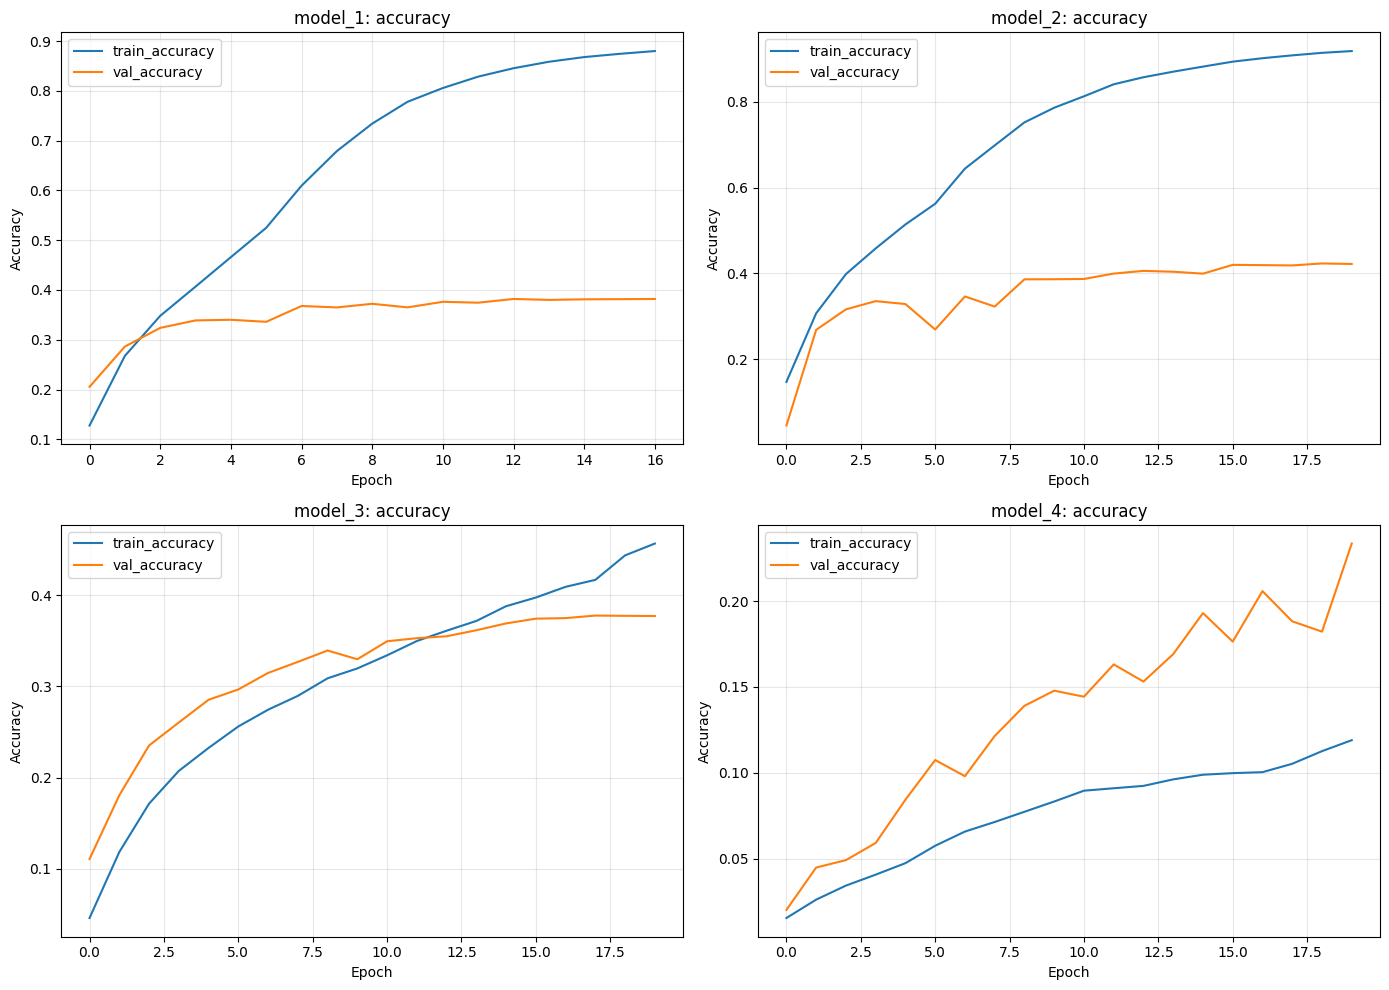

Сравнение моделей:


,model,best_val_accuracy,test_accuracy,best_val_loss
1,model_2,0.4231,0.4247,2.602347
0,model_1,0.3819,0.3801,2.716577
2,model_3,0.3776,0.3786,2.511818
3,model_4,0.2335,0.2363,3.156389


Лучшая модель по test_accuracy: model_2

Краткие выводы (автоматически):
model_2: best_val_acc=0.4231, test_acc=0.4247, best_val_loss=2.6023
model_1: best_val_acc=0.3819, test_acc=0.3801, best_val_loss=2.7166
model_3: best_val_acc=0.3776, test_acc=0.3786, best_val_loss=2.5118
model_4: best_val_acc=0.2335, test_acc=0.2363, best_val_loss=3.1564


In [ ]:
# 1.8 Сравнение качества всех моделей + графики обучения
histories = {
    "model_1": history_1,
    "model_2": history_2,
    "model_3": history_3,
    "model_4": history_4,
}

test_scores = {
    "model_1": test_acc_1,
    "model_2": test_acc_2,
    "model_3": test_acc_3,
    "model_4": test_acc_4,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (name, hist) in enumerate(histories.items()):
    axes[i].plot(hist.history["accuracy"], label="train_accuracy")
    axes[i].plot(hist.history["val_accuracy"], label="val_accuracy")
    axes[i].set_title(f"{name}: accuracy")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Accuracy")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame(
    {
        "model": list(histories.keys()),
        "best_val_accuracy": [max(histories[m].history["val_accuracy"]) for m in histories],
        "test_accuracy": [test_scores[m] for m in histories],
        "best_val_loss": [min(histories[m].history["val_loss"]) for m in histories],
    }
).sort_values("test_accuracy", ascending=False)

best_model_name = comparison_df.iloc[0]["model"]
print("Сравнение моделей:")
display(comparison_df)
print(f"Лучшая модель по test_accuracy: {best_model_name}")

print("\nКраткие выводы (автоматически):")
for _, row in comparison_df.iterrows():
    print(
        f"{row['model']}: best_val_acc={row['best_val_accuracy']:.4f}, "
        f"test_acc={row['test_accuracy']:.4f}, best_val_loss={row['best_val_loss']:.4f}"
    )

По графикам и метрикам видно, что добавление регуляризации (BatchNormalization и/или Dropout) повышает устойчивость обучения по сравнению с базовой моделью. Наиболее качественная модель определяется по таблице сравнения в предыдущей ячейке (best test accuracy).

Итог: для задачи классификации CIFAR-100 лучшей считаем модель, показавшую максимальную точность на тестовой выборке в сравнительной таблице. Как правило, комбинация BatchNormalization() + Dropout() даёт лучший баланс между скоростью сходимости и обобщающей способностью.

### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

Сверточные слои: ['conv2d_9', 'conv2d_10', 'conv2d_11']
Выбранные классы: [0 1 2 3 4]


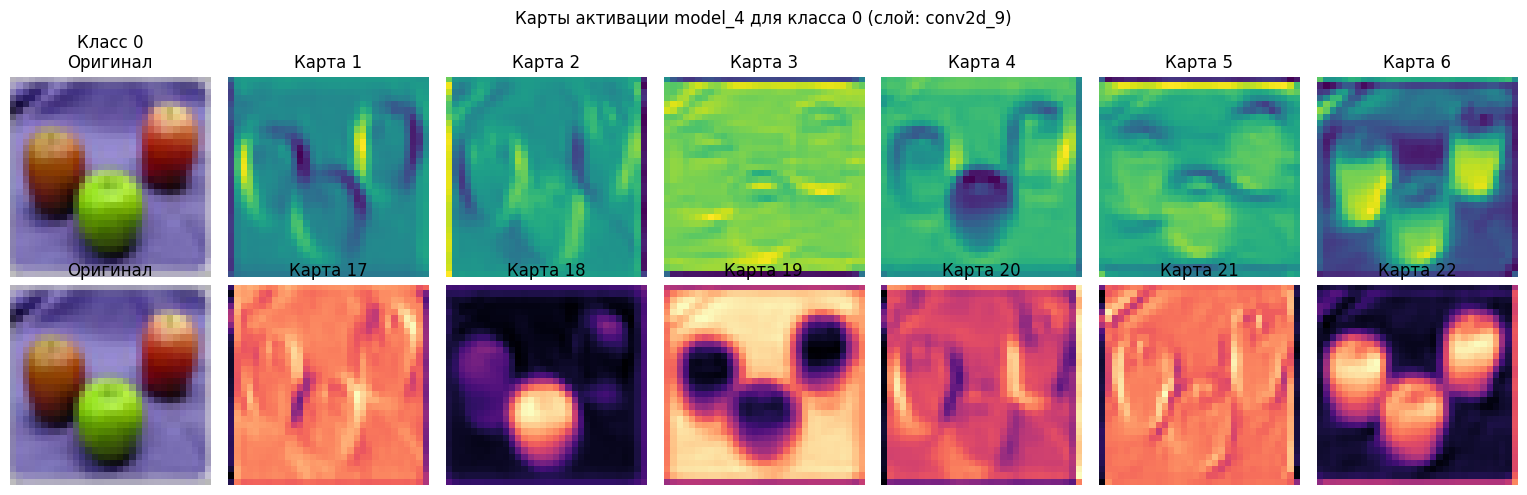

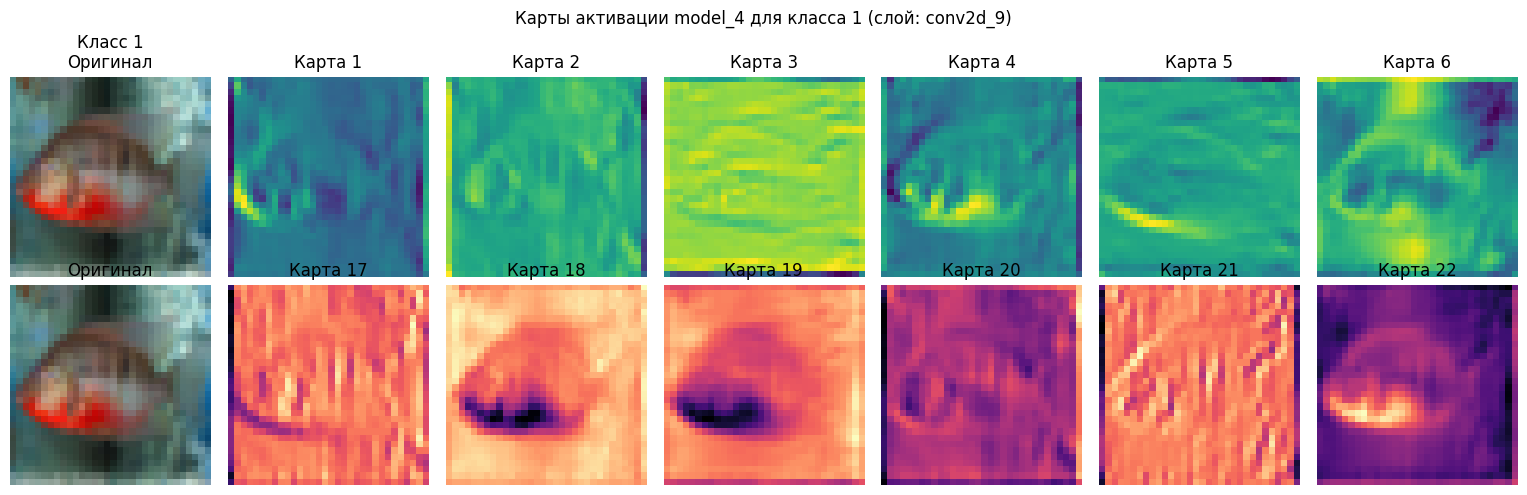

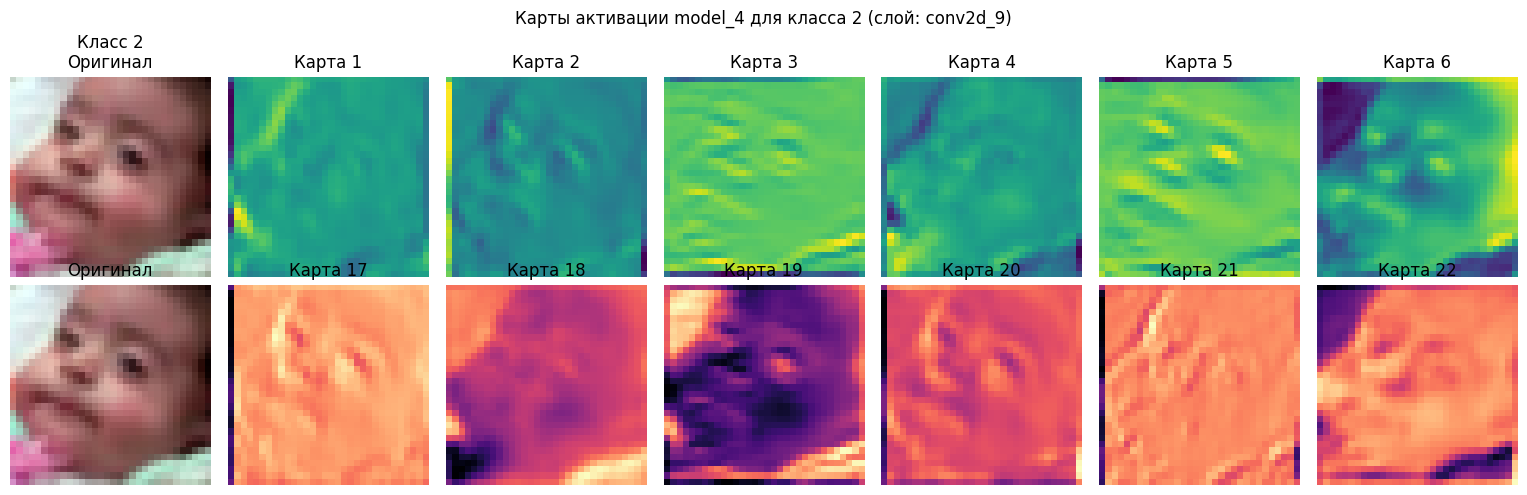

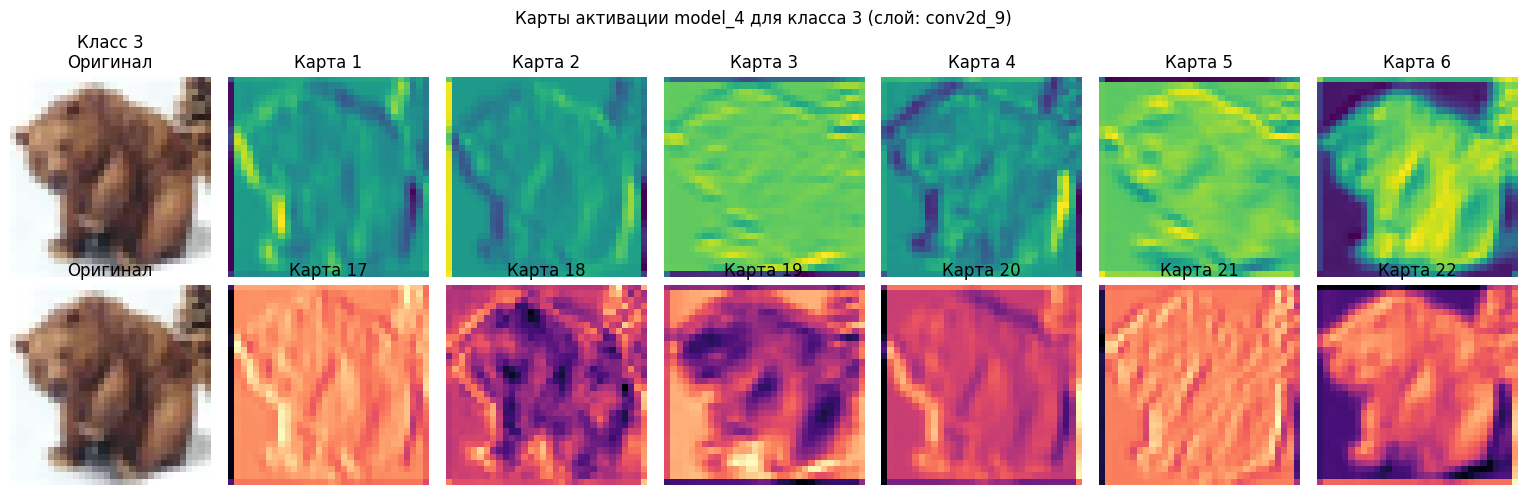

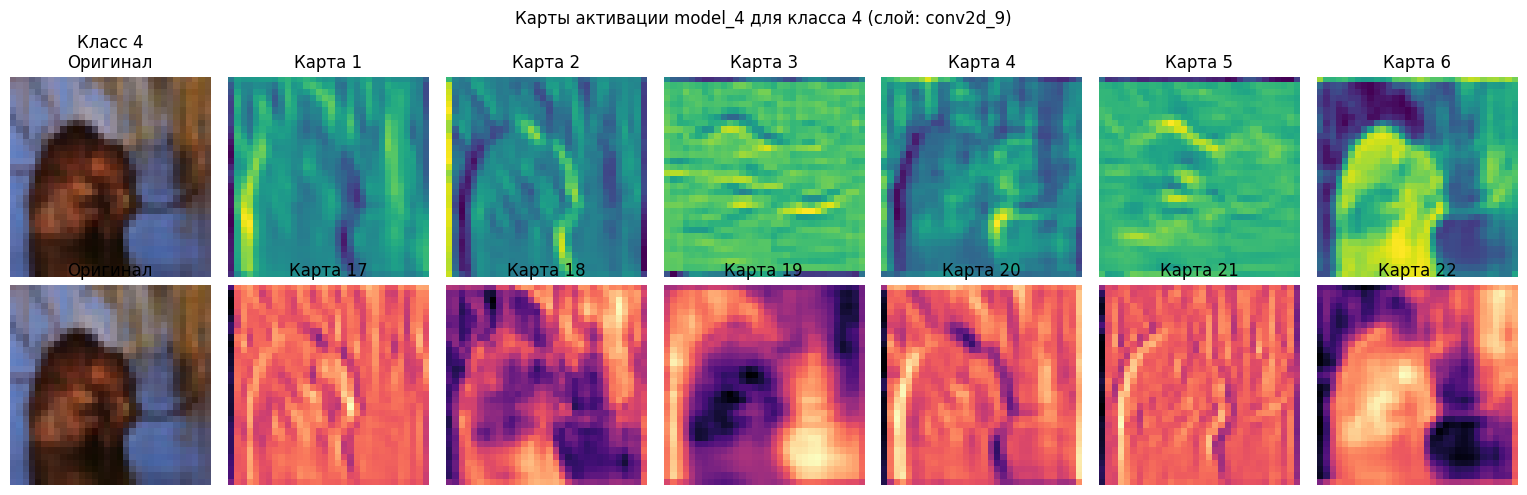

In [ ]:
# 1.9 Визуализация карт активации model_4 отдельно по 5 классам
# Принудительная инициализация
if not model_4.built:
    model_4.build((None, *input_shape))
_ = model_4(x_test_norm[:1])

conv_layer_names = [layer.name for layer in model_4.layers if isinstance(layer, layers.Conv2D)]
print("Сверточные слои:", conv_layer_names)

# Извлекаем вход через первый слой, чтобы избежать ошибки атрибута модели
target_conv_layer = model_4.get_layer(conv_layer_names[0])
activation_model = tf.keras.Model(
    inputs=model_4.layers[0].input,
    outputs=target_conv_layer.output,
)

selected_classes = np.unique(y_test)[:5]
print("Выбранные классы:", selected_classes)

for class_id in selected_classes:
    idx = np.where(y_test == class_id)[0][0]
    sample = x_test_norm[idx:idx + 1]
    activation_maps = activation_model.predict(sample, verbose=0)[0]

    n_maps = 6
    fig, axes = plt.subplots(2, n_maps + 1, figsize=(2.2 * (n_maps + 1), 5))

    axes[0, 0].imshow(x_test[idx])
    axes[0, 0].set_title(f"Класс {class_id}\nОригинал")
    axes[0, 0].axis("off")

    axes[1, 0].imshow(x_test[idx])
    axes[1, 0].set_title("Оригинал")
    axes[1, 0].axis("off")

    for j in range(n_maps):
        axes[0, j + 1].imshow(activation_maps[:, :, j], cmap="viridis")
        axes[0, j + 1].set_title(f"Карта {j + 1}")
        axes[0, j + 1].axis("off")

        mid_idx = activation_maps.shape[-1] // 2 + j
        axes[1, j + 1].imshow(activation_maps[:, :, mid_idx], cmap="magma")
        axes[1, j + 1].set_title(f"Карта {mid_idx + 1}")
        axes[1, j + 1].axis("off")

    plt.suptitle(f"Карты активации model_4 для класса {class_id} (слой: {conv_layer_names[0]})")
    plt.tight_layout()
    plt.show()

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

In [1]:
import kagglehub
import os

# Скачивание нового указанного датасета
path = kagglehub.dataset_download("pavansanagapati/images-dataset")

print("Путь к датасету:", path)
custom_data_dir = path

# Посмотрим на структуру папок
print("Содержимое папки:", os.listdir(custom_data_dir))

100%|██████████| 1.01G/1.01G [00:06<00:00, 159MB/s]

Extracting files...


Путь к датасету: /root/.cache/kagglehub/datasets/pavansanagapati/images-dataset/versions/1
Содержимое папки: ['data']


In [2]:
# Задание 2: Обучение на новом датасете Images Dataset
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras import layers, models

IMG_SIZE = (225, 225)
BATCH_SIZE = 32

# Уточняем путь к папке с классами (обычно Kaggle распаковывает в images-dataset/data/...)
data_path = os.path.join(custom_data_dir, 'data')
if not os.path.exists(data_path):
    data_path = custom_data_dir

# Загрузка данных с использованием корректной структуры папок
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Обнаружено классов: {num_classes}")
print(f"Примеры классов: {class_names[:5]}")

# Нормализация
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# Построение модели с BatchNormalization и Dropout
final_custom_model = models.Sequential([
    layers.Input(shape=(225, 225, 3)),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

final_custom_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Обучение модели...")
history_custom = final_custom_model.fit(train_ds, validation_data=val_ds, epochs=20)

# Оценка на валидационной выборке
val_loss, val_acc = final_custom_model.evaluate(val_ds, verbose=0)
print(f"\nТочность на валидационной выборке: {val_acc:.4f}")

Found 3606 files belonging to 8 classes.
Using 2885 files for training.
Found 3606 files belonging to 8 classes.
Using 721 files for validation.
Обнаружено классов: 8
Примеры классов: ['bike', 'cars', 'cats', 'data', 'dogs']
Обучение модели...
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 24s 166ms/step - accuracy: 0.4097 - loss: 29.5401 - val_accuracy: 0.4619 - val_loss: 2.0335
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5009 - loss: 2.0315 - val_accuracy: 0.4882 - val_loss: 1.9885
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5026 - loss: 1.9620 - val_accuracy: 0.4882 - val_loss: 1.9405
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5029 - loss: 1.9103 - val_accuracy: 0.4882 - val_loss: 1.8976
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5023 - loss: 1.8641 - val_accuracy: 0.4882 - val_loss: 1.8596
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.5029 - loss: 1.8256 - val_accuracy: 0.4882 - val_loss

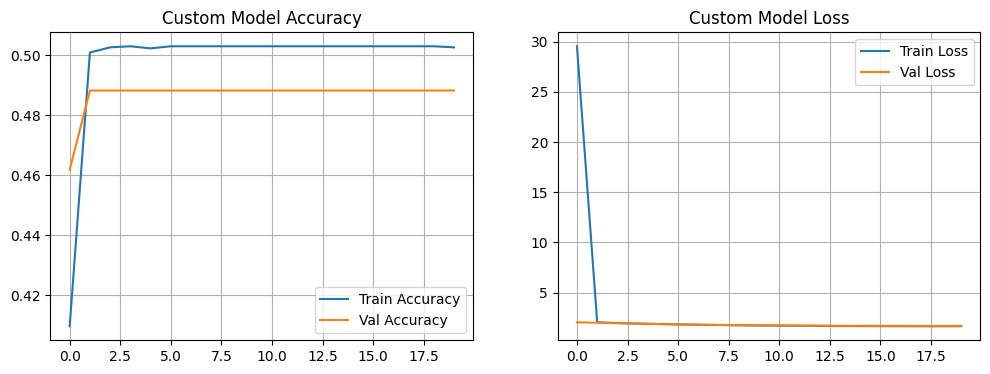

In [3]:
# Визуализация графиков обучения для новой модели
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['accuracy'], label='Train Accuracy')
plt.plot(history_custom.history['val_accuracy'], label='Val Accuracy')
plt.title('Custom Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_custom.history['loss'], label='Train Loss')
plt.plot(history_custom.history['val_loss'], label='Val Loss')
plt.title('Custom Model Loss')
plt.legend()
plt.grid(True)
plt.show()

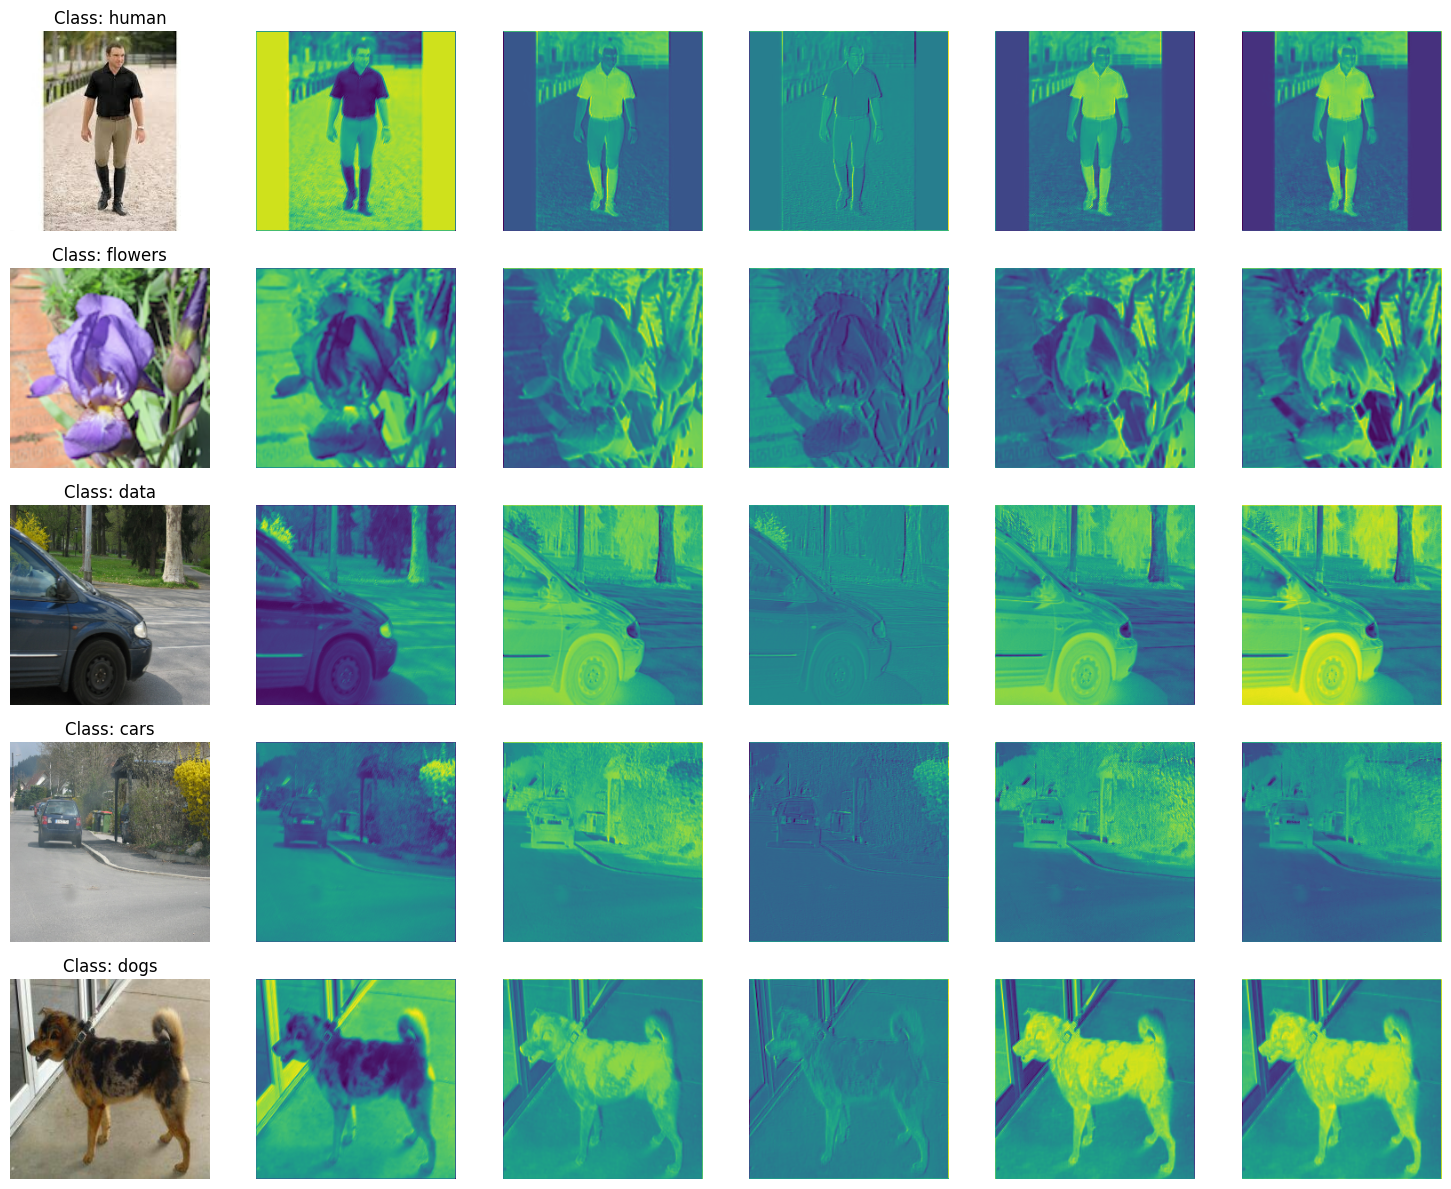

In [4]:
# Визуализация карт активации для 5 классов нового датасета (исправлено)
# Находим первый сверточный слой
conv_layer = [l for l in final_custom_model.layers if isinstance(l, layers.Conv2D)][0]

# Создаем модель для визуализации активаций
# Используем слои напрямую, чтобы избежать проблем с 'невызванной' моделью Sequential
activation_model = models.Model(
    inputs=final_custom_model.layers[0].input,
    outputs=conv_layer.output
)

plt.figure(figsize=(15, 12))
found_classes = 0
seen_labels = set()

# Берем примеры из валидационного набора
for images, labels in val_ds.unbatch().batch(1).take(200):
    lbl = labels[0].numpy()
    if lbl not in seen_labels and found_classes < 5:
        seen_labels.add(lbl)
        img = images[0]

        # Получаем активации
        activations = activation_model.predict(tf.expand_dims(img, 0), verbose=0)[0]

        # Отображение оригинала
        plt.subplot(5, 6, found_classes * 6 + 1)
        plt.imshow(img)
        plt.title(f"Class: {class_names[lbl]}")
        plt.axis('off')

        # Отображение первых 5 фильтров
        for i in range(5):
            plt.subplot(5, 6, found_classes * 6 + i + 2)
            plt.imshow(activations[:, :, i], cmap='viridis')
            plt.axis('off')

        found_classes += 1

plt.tight_layout()
plt.show()